# Insurance Charges Data Analysis - Notebook

## Welcome to Your Data Analysis Journey! 🚀

In this hands-on workshop, you'll analyze real Insurance charges data to uncover customers’ demographic and health information along with medical insurance charges insights. You'll work with over 2000 records from an online retail store.


### The Business Scenario:
You are a Junior Data Analyst at a health insurance company. The company wants to identify which factors influence insurance charges the most (e.g.,
age, BMI, smoking status). These insights will help in pricing policies and advising
customers:
- Clean and prepare the dataset
- Explore and analyse relationships between features and insurance charges
- Create meaningful visualisations using Pandas, Matplotlib, and Seaborn
- Summarise your findings and present them to your manager.

Let's get started! 📊

## Step 1: Import Required Libraries

First, let's import all the Python libraries we'll need for our analysis.

In [78]:
# TODO: Import the necessary libraries for data analysis and visualization
# Hint: You'll need pandas, numpy, matplotlib.pyplot, seaborn, and warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Data Loading & Initial Inspection

Now let's load our e-commerce dataset and take a first look at it.

In [79]:
# Load the dataset
# TODO: Load the CSV file using pandas
df = pd.read_csv('insurance.csv', encoding='latin1')
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset loaded successfully!
Shape: (1338, 7)
Memory usage: 0.25 MB


In [80]:
# Step 1: Import & Inspect the Data
#Load the dataset with Pandas. Explore with .head(), .info(), .shape(), .describe(). List
#columns and meanings.

print(f"head: {df.head}")
print(f"Info:{df.info}")
print(f"Shape: {df.shape}")
print(f"describe: {df.describe}")
print(f"list coulmns:{df.columns.tolist()}")
print(f"list Meanings:{df.dtypes.to_dict()}")

head: <bound method NDFrame.head of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>
Info:<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900     

In [81]:
# TODO: Get basic information about the dataset
# Hint: Use .info() method to see data types and non-null counts
print("Dataset Information:")
# Dataset information
print("Dataset Information:")
print(df.info())
print("\nColumn descriptions:")
print("- Age: Age of person")
print("- Sex: Gender of person")
print("- BMI: Body Mass Index")
print("- Children: Number of children")
print("- Smoker: is a person smoker or not")
print("- Region: Region of the person")
print("- Charges: Charges of insurance")


Dataset Information:
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Column descriptions:
- Age: Age of person
- Sex: Gender of person
- BMI: Body Mass Index
- Children: Number of children
- Smoker: is a person smoker or not
- Region: Region of the person
- Charges: Charges of insurance


In [82]:
# TODO: Generate descriptive statistics
# Hint: Use .describe() method
print("Descriptive Statistics:")
# Descriptive statistics
print("Descriptive Statistics:")
df.describe()


Descriptive Statistics:
Descriptive Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 🤔 Reflection Questions:
1. How many transactions are in our dataset?
2. What columns do we have?
3. Do you notice any missing values?
4. What's unusual about the minimum Quantity and UnitPrice values?

## Step 3: Data Cleaning

Before analysis, we need to clean our data. Let's identify and handle issues like missing values, duplicates, and invalid entries.

In [83]:
# Step 2: Clean data
# Check for missing values
print("Missing Values Count:")
print("Missing Values Analysis:")
missing_summary = df.isnull().sum()
missing_pct = (missing_summary / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Missing %': missing_pct
})
print(missing_df)

Missing Values Count:
Missing Values Analysis:
          Missing Count  Missing %
age                   0        0.0
sex                   0        0.0
bmi                   0        0.0
children              0        0.0
smoker                0        0.0
region                0        0.0
charges               0        0.0


In [84]:
# Identify data quality issues
print("Data Quality Issues:")
print(f"Negative age: {(df['age'] < 0).sum():,}")
print(f"Zero age: {(df['age'] == 0).sum():,}")
print(f"Negative charges: {(df['charges'] < 0).sum():,}")
print(f"Zero charges: {(df['charges'] == 0).sum():,}")
print(f"Missing region: {df['region'].isnull().sum():,}")
print(f"Missing children count: {df['children'].isnull().sum():,}")


Data Quality Issues:
Negative age: 0
Zero age: 0
Negative charges: 0
Zero charges: 0
Missing region: 0
Missing children count: 0


In [85]:
# Create clean dataset
print(f"Original dataset shape: {df.shape}")
# Apply cleaning filters
df_clean = df[
    (df['sex'].notna()) &  # Remove missing customer IDs
    (df['charges'] > 0) &        # Remove zero/negative quantities
    (df['age'] > 0)     # Remove zero/negative prices
  ].copy()
print(f"Clean dataset shape: {df_clean.shape}")
print(f"Removed {df.shape[0] - df_clean.shape[0]:,} rows ({(df.shape[0] - df_clean.shape[0])/df.shape[0]*100:.1f}%)")
print(f"Retained {len(df_clean):,} transactions for analysis")
df_clean.to_csv('cleaned_insurance.csv', index=False)

Original dataset shape: (1338, 7)
Clean dataset shape: (1338, 7)
Removed 0 rows (0.0%)
Retained 1,338 transactions for analysis


**Dropping Duplicate**

In [86]:
# To check the duplicate

print("Duplicate rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after dropping:", df_clean.duplicated().sum())

Duplicate rows: 1
Duplicate rows after dropping: 0


## Step 4: Data Transformation

Create bmi_category (Underweight, Normal, Overweight, Obese). Create age_group
(Young, Middle-aged, Senior).

In [87]:
# Step 3: Calculate EDA
print("*****Pandas analysis outputs*****")
print("Average charges:", df_clean['charges'].mean())
print("Min charges:", df_clean['charges'].min())
print("Max charges:", df_clean['charges'].max())
print(df_clean['smoker'].value_counts())

*****Pandas analysis outputs*****
Average charges: 13279.121486655948
Min charges: 1121.8739
Max charges: 63770.42801
smoker
no     1063
yes     274
Name: count, dtype: int64


In [88]:
#  Step 4: Transformations
bins = [0, 18.5, 25, 30, 100]
labels = ["Underweight", "Normal", "Overweight", "Obese"]
df_clean['bmi_category'] = pd.cut(df_clean['bmi'], bins=bins, labels=labels)

def age_group(x):
    if x < 30:
        return "Young"
    elif x < 60:
        return "Middle-aged"
    return "Senior"

df_clean['age_group'] = df_clean['age'].apply(age_group)
print(f"Newly added columns:", df_clean['age_group'].head(),df_clean['bmi_category'].head())


Newly added columns: 0          Young
1          Young
2          Young
3    Middle-aged
4    Middle-aged
Name: age_group, dtype: object 0    Overweight
1         Obese
2         Obese
3        Normal
4    Overweight
Name: bmi_category, dtype: category
Categories (4, object): ['Underweight' < 'Normal' < 'Overweight' < 'Obese']


## Step 5: Data Visualization with Matplotlib

Create bar chart (average charges by region), line chart (average charges by age), pie
chart (smoker vs non-smoker).

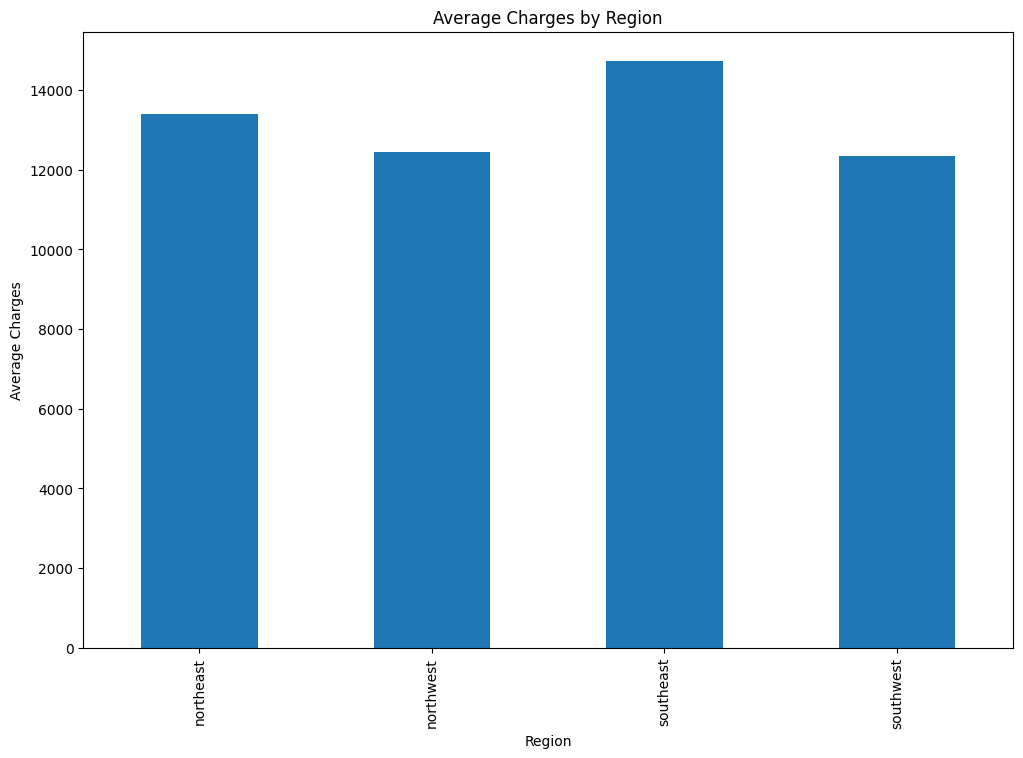

In [89]:
# Step 5.1: Matplotlib Visualisations for Average Charges by Region
plt.figure(figsize=(12,8))
df_clean.groupby('region')['charges'].mean().plot(kind='bar', title='Average Charges by Region',color='#1f77b4')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.savefig('Matplotlib Visual for avg_charges_by_region.png')
plt.show()

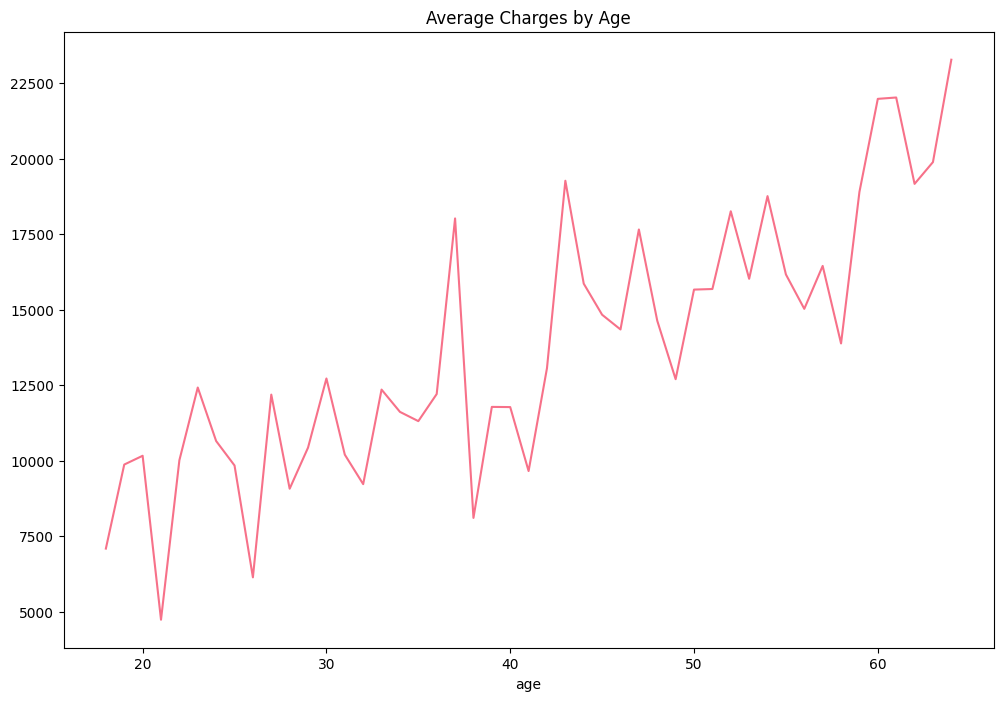

In [90]:
#  5.2:Matplotlib Visualisations for Average Charges by Age

plt.figure(figsize=(12,8))
df_clean.groupby('age')['charges'].mean().plot(title='Average Charges by Age')
plt.savefig('Matplotlib Visual for avg_charges_by_age.png')
plt.show()

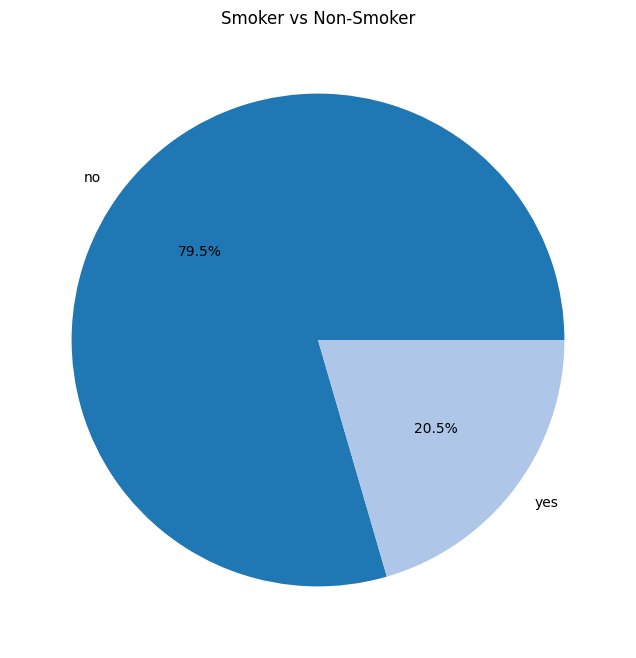

In [91]:
#  5.3:Matplotlib Visualisations for Smoker VS Non-Smoker

plt.figure(figsize=(12,8))
df_clean['smoker'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Smoker vs Non-Smoker',colors = ['#1f77b4', '#aec7e8'])
plt.ylabel("")
plt.savefig('Matplotlib Visual for smoker_pie_chart.png')
plt.show()



## Step 6: Advanced Visualization with Seaborn

Create histogram (charges), boxplot (smoker vs non-smoker), scatter plot (BMI vs
charges), heatmap (correlations).

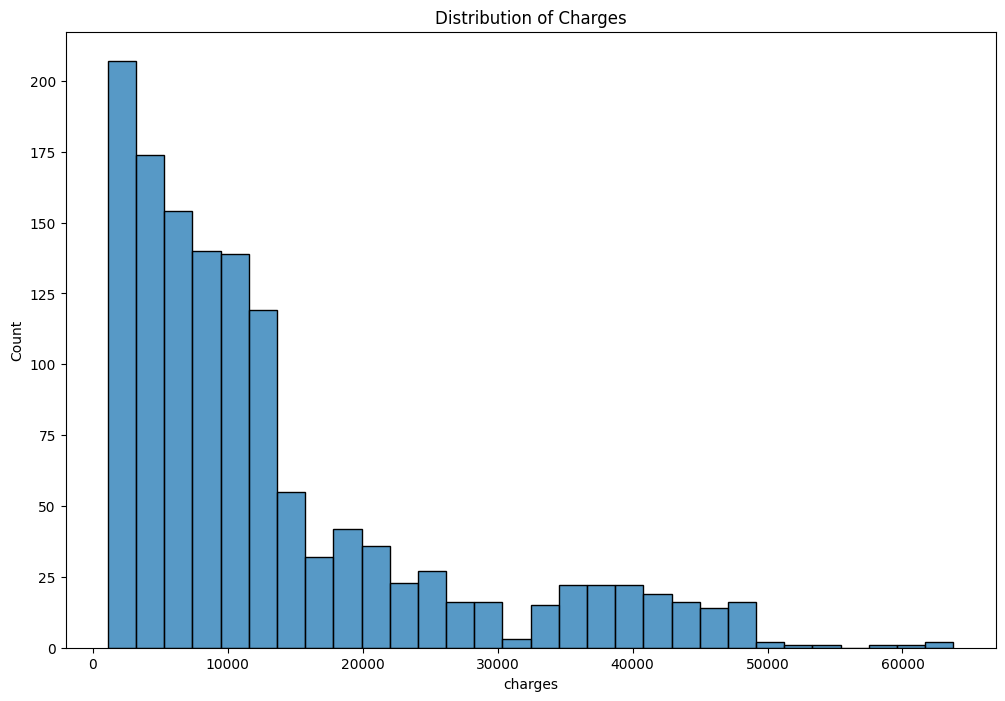

In [92]:
# Step 6.1: Seaborn Visualisations
plt.figure(figsize=(12,8))
sns.histplot(df_clean['charges'], bins=30, kde=False,color = '#1f77b4')
plt.title('Distribution of Charges')
plt.savefig('Seaborn Visual for charges_histogram.png')
plt.show()


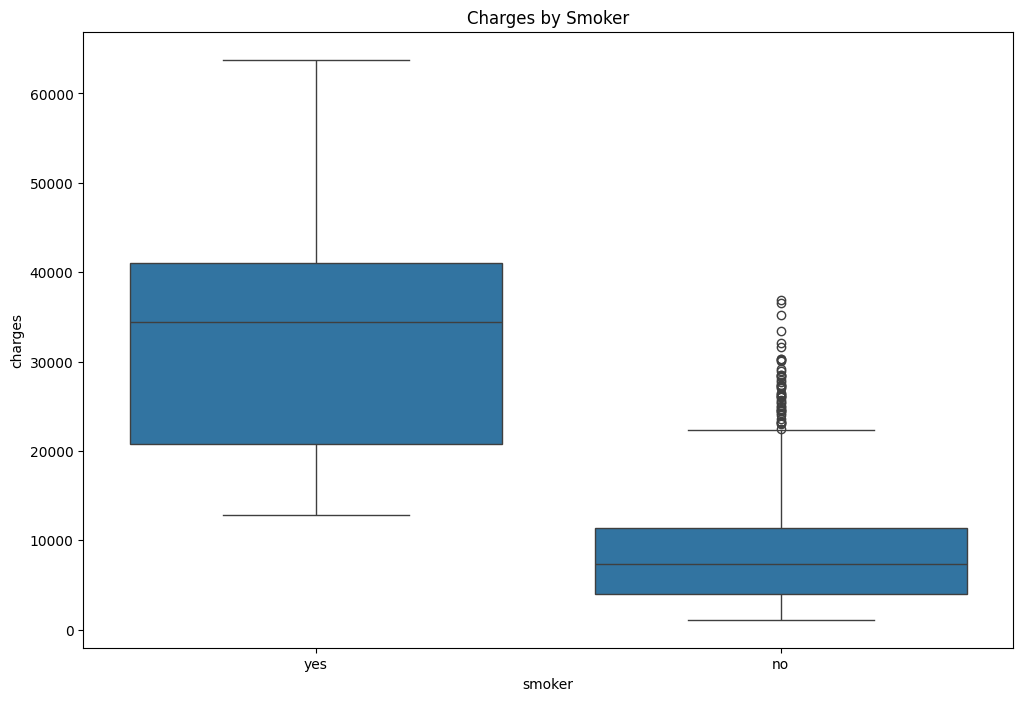

In [93]:
# Step 6.2: Seaborn Visualisations
plt.figure(figsize=(12,8))
sns.boxplot(x='smoker', y='charges', data=df_clean,color = '#1f77b4')
plt.title('Charges by Smoker')
plt.savefig('Seaborn Visual for charges_by_smoker_boxplot.png')
plt.show()


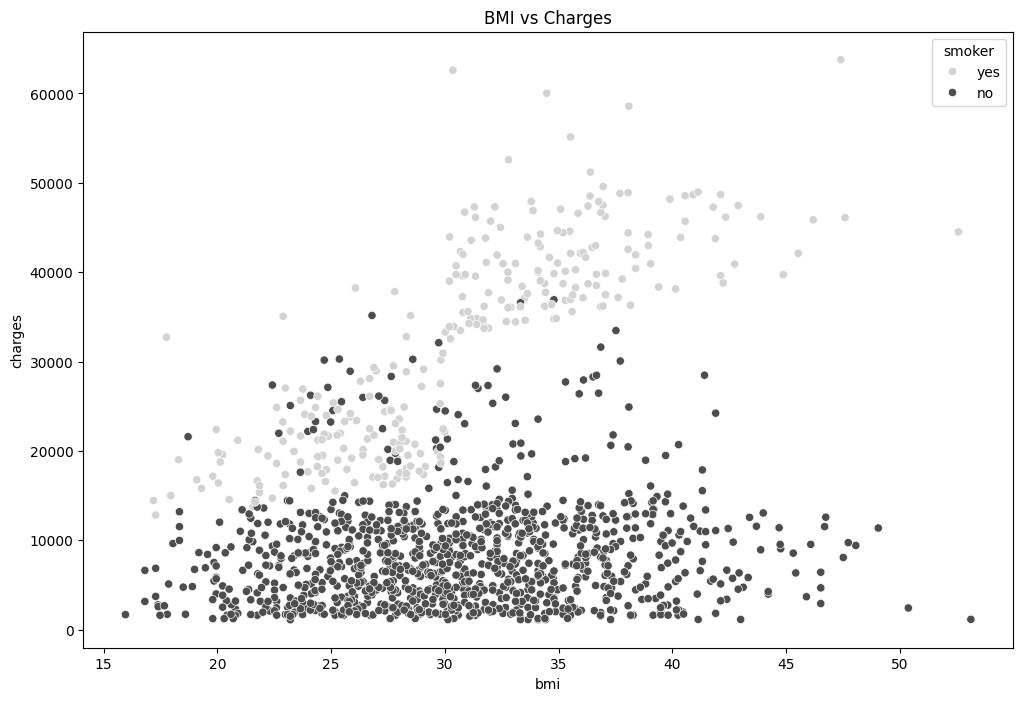

In [94]:
# Step 6.3: Seaborn Visualisations
plt.figure(figsize=(12,8))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df_clean, palette= ['#d3d3d3', '#4d4d4d'])
plt.title('BMI vs Charges')
plt.savefig('Seaborn Visual for bmi_vs_charges_scatter.png')
plt.show()


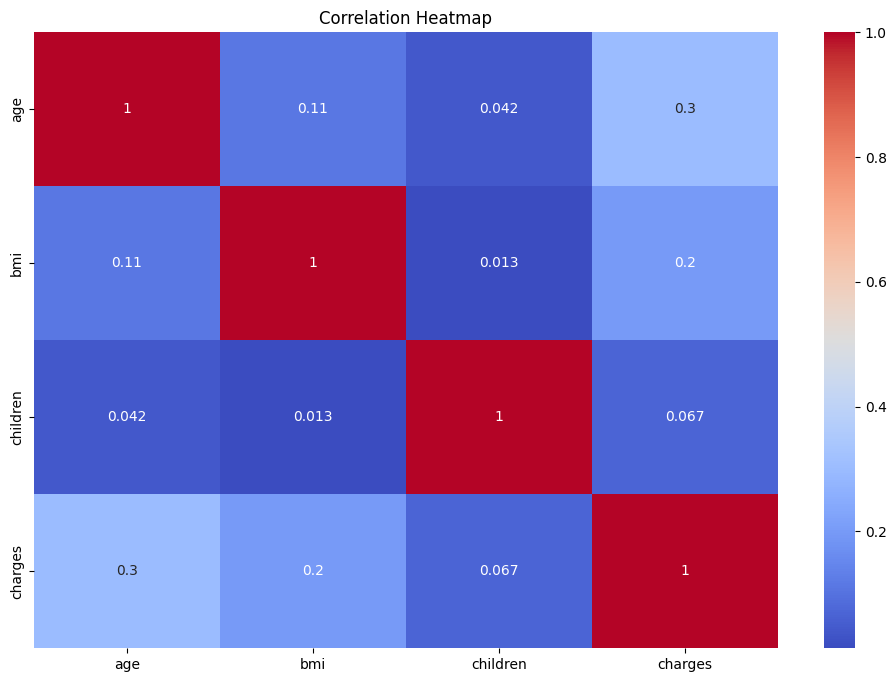

In [95]:
# Step 6.4: Seaborn Visualisations
plt.figure(figsize=(12,8))
corr = df_clean[['age','bmi','children','charges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('Seaborn Visual for correlation_heatmap.png')
plt.show()

## Step 7: Business Insights & Reflection

Summarise findings:
- smokers vs non-smokers,
- BMI effect,
- age impact,
- regional differences.


🔄 Average charges by smoking status:
 smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


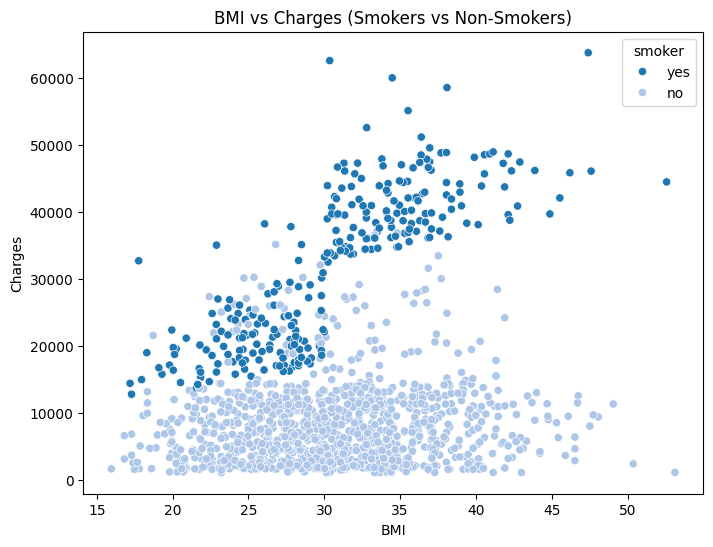

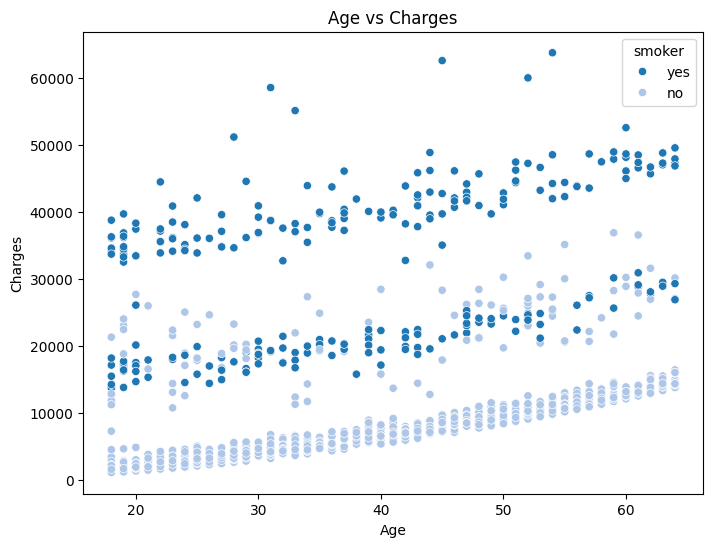


 💵 Average charges by region:
 region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


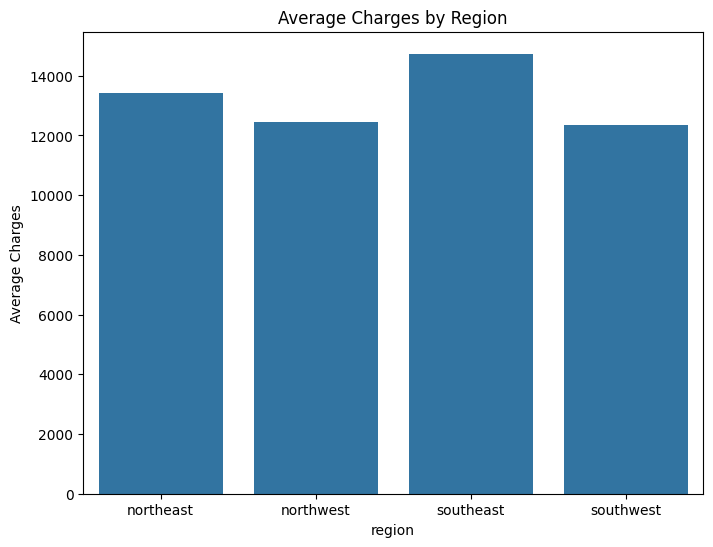

In [96]:
# Calculate key business metrics

# 1. Smokers vs Non-Smokers
smoker_avg = df_clean.groupby('smoker')['charges'].mean()
print("🔄 Average charges by smoking status:\n", smoker_avg)

# 2. BMI effect
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clean, x='bmi', y='charges', hue='smoker',palette= ['#1f77b4', '#aec7e8'])
plt.title('BMI vs Charges (Smokers vs Non-Smokers)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

# 3. Age impact
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clean, x='age', y='charges', hue='smoker',palette= ['#1f77b4', '#aec7e8'])
plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

# 4. Regional differences
region_avg = df_clean.groupby('region')['charges'].mean()
print("\n 💵 Average charges by region:\n", region_avg)

# Optional: visualize regional differences
plt.figure(figsize=(8,6))
sns.barplot(x=region_avg.index, y=region_avg.values,color = '#1f77b4')
plt.title('Average Charges by Region')
plt.ylabel('Average Charges')
plt.show()


Reflection question: If you were advising the company, which three factors
are the strongest drivers of charges and why?

In [97]:
# Define a summary of strongest drivers of insurance charges
business_insights = {
    "strongest_drivers": [
        {
            "factor": "Smoking Status",
            "reason": "Smokers face significantly higher medical risks, leading to higher insurance claims.",
            "impact": "Charges for smokers can be 2–3 times higher than non-smokers.",
            "business_implication": "Most influential factor in determining premiums."
        },
        {
            "factor": "Age",
            "reason": "Health risks increase with age, especially for chronic conditions.",
            "impact": "Older individuals generally incur higher medical costs.",
            "business_implication": "Predictable driver that insurers can model to adjust pricing."
        },
        {
            "factor": "BMI",
            "reason": "Higher BMI is linked to obesity-related conditions like diabetes and heart disease.",
            "impact": "Individuals with higher BMI tend to have higher charges, even within the same age group.",
            "business_implication": "Key health indicator interacting with age and lifestyle to influence costs."
        }
    ],
    "optional_insights": "Region and gender may have minor effects, but smoking, age, and BMI explain the majority of variance in insurance charges."
}

print("Business Insights:")
print("-" * 60)
for driver in business_insights["strongest_drivers"]:
    print(f"Factor: {driver['factor']}")
    print(f"Reason: {driver['reason']}")
    print(f"Impact: {driver['impact']}")
    print(f"Business Implication: {driver['business_implication']}")
    print("-" * 60)

print("Optional Insights:", business_insights["optional_insights"])




Business Insights:
------------------------------------------------------------
Factor: Smoking Status
Reason: Smokers face significantly higher medical risks, leading to higher insurance claims.
Impact: Charges for smokers can be 2–3 times higher than non-smokers.
Business Implication: Most influential factor in determining premiums.
------------------------------------------------------------
Factor: Age
Reason: Health risks increase with age, especially for chronic conditions.
Impact: Older individuals generally incur higher medical costs.
Business Implication: Predictable driver that insurers can model to adjust pricing.
------------------------------------------------------------
Factor: BMI
Reason: Higher BMI is linked to obesity-related conditions like diabetes and heart disease.
Impact: Individuals with higher BMI tend to have higher charges, even within the same age group.
Business Implication: Key health indicator interacting with age and lifestyle to influence costs.
-------

**To save a word document with summary of Business Insights**

In [98]:
!pip install python-docx

In [99]:

from docx import Document

doc = Document()
doc.add_heading('Business Insights', level=1)

# Add each strongest driver
for driver in business_insights["strongest_drivers"]:
    doc.add_heading(f"Factor: {driver['factor']}", level=2)
    doc.add_paragraph(f"Reason: {driver['reason']}")
    doc.add_paragraph(f"Impact: {driver['impact']}")
    doc.add_paragraph(f"Business Implication: {driver['business_implication']}")
    doc.add_paragraph("------------------------------------------------------------")

# Add optional insights at the end
doc.add_heading("Optional Insights", level=2)
doc.add_paragraph(business_insights["optional_insights"])

# Save the document
doc.save('Business_Insights.docx')
